## 스포츠 센터 분석
- 배경:자주 이용하는 고객은 계속 오지만, 가끔 오는 고객은 어느새 오지 않음
어떤 고객이 계속 이용하고 있는지 데이터 분석을 통해서 알 수 있을까?

- 데이터 파일 설명 
    - 센터 이용 이력 데이터
    - 기간: 2018년 4월 ~ 2019년 3원 (1년)
    - 회원 구분: 종일회원, 주간회원, 야간 회원 
    - 행사 구분: 비정기적 입회비 반액 할인 or 무료 행사 
    - 탈퇴: 월말까지 신청-> 다음달 말 탈퇴 

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd


In [64]:
uselog = pd.read_csv('data/use_log.csv')
uselog.shape
uselog.head()

# 고객id, 이용 날짜

,log_id,customer_id,usedate
0,L00000049012330,AS009373,2018-04-01
1,L00000049012331,AS015315,2018-04-01
2,L00000049012332,AS040841,2018-04-01
3,L00000049012333,AS046594,2018-04-01
4,L00000049012334,AS073285,2018-04-01


In [ ]:
uselog.info()
# 날짜가 현재 str -> datetime으로 변환 필요
# 결측치는 없음 

<class 'pandas.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   log_id       197428 non-null  str  
 1   customer_id  197428 non-null  str  
 2   usedate      197428 non-null  str  
dtypes: str(3)
memory usage: 4.5 MB


In [ ]:
customer = pd.read_csv('data/customer_master.csv')
customer.head(),customer.shape

# 고객 정보(개인 정보 및 가입/탈퇴 정보)

(  customer_id   name class gender           start_date end_date campaign_id  \
 0    OA832399   XXXX   C01      F  2015-05-01 00:00:00      NaN         CA1   
 1    PL270116  XXXXX   C01      M  2015-05-01 00:00:00      NaN         CA1   
 2    OA974876  XXXXX   C01      M  2015-05-01 00:00:00      NaN         CA1   
 3    HD024127  XXXXX   C01      F  2015-05-01 00:00:00      NaN         CA1   
 4    HD661448  XXXXX   C03      F  2015-05-01 00:00:00      NaN         CA1   
 
    is_deleted  
 0           0  
 1           0  
 2           0  
 3           0  
 4           0  ,
 (4192, 8))

In [15]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  4192 non-null   str  
 1   name         4192 non-null   str  
 2   class        4192 non-null   str  
 3   gender       4192 non-null   str  
 4   start_date   4192 non-null   str  
 5   end_date     1350 non-null   str  
 6   campaign_id  4192 non-null   str  
 7   is_deleted   4192 non-null   int64
dtypes: int64(1), str(7)
memory usage: 262.1 KB


In [ ]:
class_master = pd.read_csv('data/class_master.csv')
class_master

# 회원 구분별 가격 

,class,class_name,price
0,C01,0_종일,10500
1,C02,1_주간,7500
2,C03,2_야간,6000


In [ ]:
campaign = pd.read_csv('data/campaign_master.csv')
campaign

#가입시 행사 

,campaign_id,campaign_name
0,CA1,2_일반
1,CA2,0_입회비반액할인
2,CA3,1_입회비무료


### 같은 컬럼 이용해 테이블 합치기(merge)

- 회원 구분 정보 추가 (class) 
- 할인 정보 추가 (campagin)

In [21]:
customer_join = pd.merge(customer, class_master, how='left', on='class')
customer_join.head(2)
# 회원정보는 모두 출력되어야 함 -> left join

,customer_id,name,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price
0,OA832399,XXXX,C01,F,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500
1,PL270116,XXXXX,C01,M,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500


In [22]:
customer_join = pd.merge(customer_join, campaign, how='left', on='campaign_id')
customer_join.head(2)

,customer_id,name,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price,campaign_name
0,OA832399,XXXX,C01,F,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
1,PL270116,XXXXX,C01,M,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반


In [23]:
customer_join.info()

<class 'pandas.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    4192 non-null   str  
 1   name           4192 non-null   str  
 2   class          4192 non-null   str  
 3   gender         4192 non-null   str  
 4   start_date     4192 non-null   str  
 5   end_date       1350 non-null   str  
 6   campaign_id    4192 non-null   str  
 7   is_deleted     4192 non-null   int64
 8   class_name     4192 non-null   str  
 9   price          4192 non-null   int64
 10  campaign_name  4192 non-null   str  
dtypes: int64(2), str(9)
memory usage: 360.4 KB


In [24]:
customer_join.isnull().sum()

customer_id         0
name                0
class               0
gender              0
start_date          0
end_date         2842
campaign_id         0
is_deleted          0
class_name          0
price               0
campaign_name       0
dtype: int64

In [25]:
customer_join.query('is_deleted == 0')['is_deleted'].count()

np.int64(2842)

In [ ]:
# class별 회원 수 
customer_join.groupby('class_name').count()['customer_id']

class_name
0_종일    2045
1_주간    1019
2_야간    1128
Name: customer_id, dtype: int64

In [ ]:
# 가입 행사별 회원 수 
customer_join.groupby('campaign_name').count().customer_id

campaign_name
0_입회비반액할인     650
1_입회비무료       492
2_일반         3050
Name: customer_id, dtype: int64

In [ ]:
# 회원 성비 
customer_join.groupby('gender').count().customer_id

gender
F    1983
M    2209
Name: customer_id, dtype: int64

In [33]:
# 0 지속 회원 , 1 탈퇴 회원 
customer_join.groupby('is_deleted').count().customer_id

is_deleted
0    2842
1    1350
Name: customer_id, dtype: int64

#### -> 탈퇴율 32% 높은 편으로 누가, 왜 탈퇴하는지 파악하는 것이 목표

In [38]:
# 날짜 데이터 datetime으로 변환
customer_join['start_date'] = pd.to_datetime(customer_join['start_date'])

In [ ]:
# 최근 회원 데이터 접근(가입한지 얼마 안되어서 충성 고객은 아닌 상태)
customer_start = customer_join.loc[customer_join['start_date'] > pd.to_datetime('20180401')]
customer_start.shape

(1361, 11)

In [45]:
customer_join['end_date'] = pd.to_datetime(customer_join['end_date'])

In [50]:
customer_newer = customer_join.loc[(customer_join['end_date'] >= pd.to_datetime('20190331')) | 
(customer_join['end_date'].isna())]

In [51]:
customer_newer.groupby('class_name').count().customer_id

class_name
0_종일    1444
1_주간     696
2_야간     813
Name: customer_id, dtype: int64

In [52]:
customer_newer.groupby('campaign_name').count().customer_id

campaign_name
0_입회비반액할인     311
1_입회비무료       242
2_일반         2400
Name: customer_id, dtype: int64

전체 데이터와 최근 데이터를 비교했을 때, 회원구분별 집계는 큰 차이가 없고, 입회 캠페인은 회원 비율 변화에 영향을 미친다고 추축


#### 가설
1. 무료, 할인 캠페인으로 가입한 회원의 탈퇴율이 일반 가입자보다 높다
2. 회원 클래스와 성별은 탈퇴와 큰 관련이 없다.(분포 거의 동일)
3. 탈퇴는 가입 후 일정 시간 내에 집중적으로 발생한다. 

In [54]:
# 캠페인별 탈퇴율 (탈퇴회원 수 / 전체회원 수)
campaign_total = customer_join.groupby('campaign_name').count().customer_id
campaign_exit = customer_join.loc[customer_join['is_deleted'] == 1].groupby('campaign_name').count().customer_id 
campaign_total, campaign_exit

(campaign_name
 0_입회비반액할인     650
 1_입회비무료       492
 2_일반         3050
 Name: customer_id, dtype: int64,
 campaign_name
 0_입회비반액할인    368
 1_입회비무료      273
 2_일반         709
 Name: customer_id, dtype: int64)

In [56]:
# 비율로 확인
exit_rate = (campaign_exit / campaign_total * 100).round(2)
print('캠페인별 탈퇴율(%)')
print(exit_rate)

캠페인별 탈퇴율(%)
campaign_name
0_입회비반액할인    56.62
1_입회비무료      55.49
2_일반         23.25
Name: customer_id, dtype: float64


캠페인으로 들어온 뉴비들 관리 필요 (무료로 가입해서 쉽게 이탈 가능)

In [57]:
uselog.head()

,log_id,customer_id,usedate
0,L00000049012330,AS009373,2018-04-01
1,L00000049012331,AS015315,2018-04-01
2,L00000049012332,AS040841,2018-04-01
3,L00000049012333,AS046594,2018-04-01
4,L00000049012334,AS073285,2018-04-01


In [65]:
uselog['usedate'] = pd.to_datetime(uselog['usedate'])
uselog.info()

<class 'pandas.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   log_id       197428 non-null  str           
 1   customer_id  197428 non-null  str           
 2   usedate      197428 non-null  datetime64[us]
dtypes: datetime64[us](1), str(2)
memory usage: 4.5 MB


In [66]:
uselog['연월'] = uselog['usedate'].dt.strftime('%Y%m')
uselog.head()

,log_id,customer_id,usedate,연월
0,L00000049012330,AS009373,2018-04-01,201804
1,L00000049012331,AS015315,2018-04-01,201804
2,L00000049012332,AS040841,2018-04-01,201804
3,L00000049012333,AS046594,2018-04-01,201804
4,L00000049012334,AS073285,2018-04-01,201804


In [68]:
uselog_months = uselog.groupby(['연월','customer_id'],as_index=False).count()
uselog_months.head()

,연월,customer_id,log_id,usedate
0,201804,AS002855,4,4
1,201804,AS009013,2,2
2,201804,AS009373,3,3
3,201804,AS015315,6,6
4,201804,AS015739,7,7


In [69]:
uselog_months.rename(columns={'log_id':'count'},inplace=True)

In [70]:
del uselog_months['usedate']
uselog_months.head()

,연월,customer_id,count
0,201804,AS002855,4
1,201804,AS009013,2
2,201804,AS009373,3
3,201804,AS015315,6
4,201804,AS015739,7


In [79]:
uselog_customer = uselog_months.groupby('customer_id')['count'].agg(['mean','median','max','min']).reset_index(drop=False)
uselog_customer.head()

,customer_id,mean,median,max,min
0,AS002855,4.500000,5.0,7,2
1,AS008805,4.000000,4.0,8,1
2,AS009013,2.000000,2.0,2,2
3,AS009373,5.083333,5.0,7,3
4,AS015233,7.545455,7.0,11,4


In [80]:
uselog_customer[1:].describe()

,mean,median,max,min
count,4191.000000,4191.000000,4191.000000,4191.000000
mean,5.333326,5.250656,7.824147,3.041518
std,1.777699,1.875093,2.169181,1.951731
min,1.000000,1.000000,1.000000,1.000000
25%,4.250000,4.000000,7.000000,2.000000
50%,5.000000,5.000000,8.000000,3.000000
75%,6.416667,6.500000,9.000000,4.000000
max,12.000000,12.000000,14.000000,12.000000


전 회원 월 평균 5.3회, 편차 평균 +_ 2

In [81]:
# 요일 컬럼 추가
uselog['weekday'] = uselog['usedate'].dt.weekday
uselog.head()

,log_id,customer_id,usedate,연월,weekday
0,L00000049012330,AS009373,2018-04-01,201804,6
1,L00000049012331,AS015315,2018-04-01,201804,6
2,L00000049012332,AS040841,2018-04-01,201804,6
3,L00000049012333,AS046594,2018-04-01,201804,6
4,L00000049012334,AS073285,2018-04-01,201804,6


In [87]:
# 고객별, 월별, 요일별 이용 횟수
uselog_weekday = uselog.groupby(['customer_id','연월','weekday'],as_index=False).log_id.count()
uselog_weekday.head()

,customer_id,연월,weekday,log_id
0,AS002855,201804,5,4
1,AS002855,201805,2,1
2,AS002855,201805,5,4
3,AS002855,201806,5,5
4,AS002855,201807,1,1


In [89]:
uselog_weekday = uselog_weekday.rename(columns={'log_id': 'count'})
uselog_weekday.head()

,customer_id,연월,weekday,count
0,AS002855,201804,5,4
1,AS002855,201805,2,1
2,AS002855,201805,5,4
3,AS002855,201806,5,5
4,AS002855,201807,1,1


In [92]:
# u
uselog_weekday = uselog_weekday[['customer_id','count']].groupby('customer_id',as_index=False).max()
uselog_weekday.head(2)

,customer_id,count
0,AS002855,5
1,AS008805,4


In [93]:
uselog_weekday['routine_flg'] = 0
uselog_weekday['routine_flg'] = uselog_weekday['routine_flg'].where(uselog_weekday['count'] < 4,1)
uselog_weekday.head()

,customer_id,count,routine_flg
0,AS002855,5,1
1,AS008805,4,1
2,AS009013,2,0
3,AS009373,5,1
4,AS015233,5,1


In [ ]:
# 정기 vs 비정기
uselog_weekday.groupby('routine_flg').count().customer_id

# 정기적으로 나오는 사람(매주 같은 요일 습관)이 81%(3,413명)
# 비정기적 회원이 이탈율 높음 

routine_flg
0     779
1    3413
Name: customer_id, dtype: int64

In [98]:
customer_join = pd.merge(customer_join, uselog_customer, how = 'left', on='customer_id')
customer_join = pd.merge(customer_join, uselog_weekday[['customer_id','routine_flg']], how='left', on='customer_id')
customer_join.head()

,customer_id,name,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price,...,mean_x,median_x,max_x,min_x,routine_flg_x,mean_y,median_y,max_y,min_y,routine_flg_y
0,OA832399,XXXX,C01,F,2015-05-01,NaT,CA1,0,0_종일,10500,...,4.833333,5.0,8,2,1,4.833333,5.0,8,2,1
1,PL270116,XXXXX,C01,M,2015-05-01,NaT,CA1,0,0_종일,10500,...,5.083333,5.0,7,3,1,5.083333,5.0,7,3,1
2,OA974876,XXXXX,C01,M,2015-05-01,NaT,CA1,0,0_종일,10500,...,4.583333,5.0,6,3,1,4.583333,5.0,6,3,1
3,HD024127,XXXXX,C01,F,2015-05-01,NaT,CA1,0,0_종일,10500,...,4.833333,4.5,7,2,1,4.833333,4.5,7,2,1
4,HD661448,XXXXX,C03,F,2015-05-01,NaT,CA1,0,2_야간,6000,...,3.916667,4.0,6,1,1,3.916667,4.0,6,1,1


In [99]:
customer_join.info()

<class 'pandas.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    4192 non-null   str           
 1   name           4192 non-null   str           
 2   class          4192 non-null   str           
 3   gender         4192 non-null   str           
 4   start_date     4192 non-null   datetime64[us]
 5   end_date       1350 non-null   datetime64[us]
 6   campaign_id    4192 non-null   str           
 7   is_deleted     4192 non-null   int64         
 8   class_name     4192 non-null   str           
 9   price          4192 non-null   int64         
 10  campaign_name  4192 non-null   str           
 11  mean_x         4192 non-null   float64       
 12  median_x       4192 non-null   float64       
 13  max_x          4192 non-null   int64         
 14  min_x          4192 non-null   int64         
 15  routine_flg_x  4192 non-null   i

In [100]:
customer_join.to_csv('./data/customer_join.csv',index=False)

In [106]:
# 현재 데이터는 2019년 3월까지의 데이터
# 탈퇴하지 않은 회원의 end_date는 현재 NaN이므로, 회원 기간을 계산을 위해 임의로 2019년 4월 30일로 데이터를 채워서 계산

# 기간 계산 라이브러리 
from dateutil.relativedelta import relativedelta  

# 회원 기간 계산
customer_join['calc_date'] = customer_join['end_date']
customer_join['calc_date'] = customer_join['end_date'].fillna(pd.to_datetime('2019-04-30'))

# 멤버십 기간
customer_join['membership_period'] = 0
for i in range(len(customer_join)):
    delta = relativedelta(customer_join.loc[i,'calc_date'], customer_join.loc[i, 'start_date'])
    customer_join.loc[i,'membership_period'] = delta.years * 12 + delta.months

In [107]:
customer_join.head()

,customer_id,name,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price,...,max_x,min_x,routine_flg_x,mean_y,median_y,max_y,min_y,routine_flg_y,calc_date,membership_period
0,OA832399,XXXX,C01,F,2015-05-01,NaT,CA1,0,0_종일,10500,...,8,2,1,4.833333,5.0,8,2,1,2019-04-30,47
1,PL270116,XXXXX,C01,M,2015-05-01,NaT,CA1,0,0_종일,10500,...,7,3,1,5.083333,5.0,7,3,1,2019-04-30,47
2,OA974876,XXXXX,C01,M,2015-05-01,NaT,CA1,0,0_종일,10500,...,6,3,1,4.583333,5.0,6,3,1,2019-04-30,47
3,HD024127,XXXXX,C01,F,2015-05-01,NaT,CA1,0,0_종일,10500,...,7,2,1,4.833333,4.5,7,2,1,2019-04-30,47
4,HD661448,XXXXX,C03,F,2015-05-01,NaT,CA1,0,2_야간,6000,...,6,1,1,3.916667,4.0,6,1,1,2019-04-30,47


In [108]:
customer_join.loc[customer_join['is_deleted']==1,['customer_id','start_date','end_date','calc_date','membership_period']]

,customer_id,start_date,end_date,calc_date,membership_period
708,TS511179,2016-05-01,2018-04-30,2018-04-30,23
729,TS443736,2016-05-01,2018-04-30,2018-04-30,23
730,HD542886,2016-05-01,2018-04-30,2018-04-30,23
770,HD597545,2016-06-01,2018-05-31,2018-05-31,23
785,HI749296,2016-06-01,2018-05-31,2018-05-31,23
...,...,...,...,...,...
4049,OA143589,2019-01-15,2019-02-28,2019-02-28,1
4050,GD367382,2019-01-15,2019-03-31,2019-03-31,2
4068,OA034442,2019-02-05,2019-03-31,2019-03-31,1
4086,PL508278,2019-02-09,2019-03-31,2019-03-31,1


<Axes: ylabel='Frequency'>

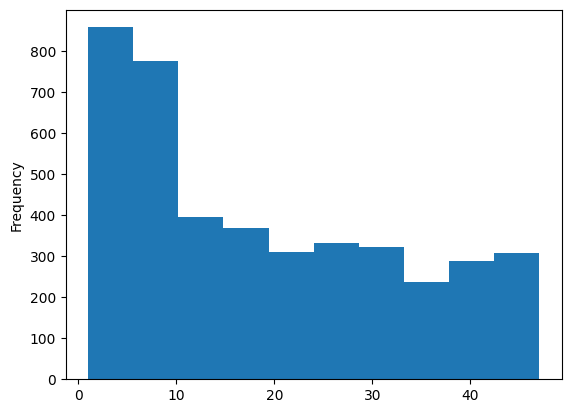

In [ ]:
customer_join['membership_period'].plot.hist()

# 10개월이전 이탈율 높음 

In [110]:
exit_period = customer_join.loc[customer_join['is_deleted']==1, 'membership_period']
stay_period = customer_join.loc[customer_join['is_deleted']==0, 'membership_period']

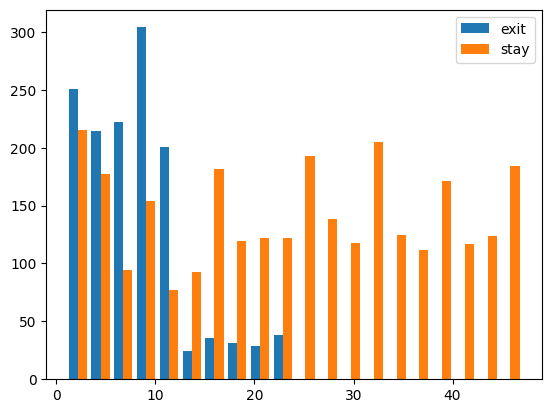

In [113]:
import matplotlib.pyplot as plt
plt.hist([exit_period,stay_period],bins=20,label = ['exit','stay'],stacked=False)
plt.legend()
plt.show()

# 탈퇴 회원은 평균적으로 짧은 회원 기간
# 지속 회원은 다양한 회원 기간

In [114]:
# 탈퇴 회원 요약
customer_end = customer_join.loc[customer_join['is_deleted']==1]
customer_end.describe()

,start_date,end_date,is_deleted,price,mean_x,median_x,max_x,min_x,routine_flg_x,mean_y,median_y,max_y,min_y,routine_flg_y,calc_date,membership_period
count,1350,1350,1350.0,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350,1350.000000
mean,2018-01-20 10:45:20,2018-10-17 16:23:28,1.0,8595.555556,3.865474,3.621852,6.461481,1.821481,0.456296,3.865474,3.621852,6.461481,1.821481,0.456296,2018-10-17 16:23:28,8.026667
min,2016-05-01 00:00:00,2018-04-30 00:00:00,1.0,6000.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2018-04-30 00:00:00,1.000000
25%,2017-10-01 00:00:00,2018-06-30 00:00:00,1.0,6000.000000,3.000000,3.000000,4.000000,1.000000,0.000000,3.000000,3.000000,4.000000,1.000000,0.000000,2018-06-30 00:00:00,4.000000
50%,2018-03-01 00:00:00,2018-10-31 00:00:00,1.0,7500.000000,4.000000,4.000000,7.000000,2.000000,0.000000,4.000000,4.000000,7.000000,2.000000,0.000000,2018-10-31 00:00:00,7.000000
75%,2018-06-03 00:00:00,2019-01-31 00:00:00,1.0,10500.000000,4.666667,4.500000,8.000000,2.000000,1.000000,4.666667,4.500000,8.000000,2.000000,1.000000,2019-01-31 00:00:00,11.000000
max,2019-02-11 00:00:00,2019-03-31 00:00:00,1.0,10500.000000,9.000000,9.000000,13.000000,8.000000,1.000000,9.000000,9.000000,13.000000,8.000000,1.000000,2019-03-31 00:00:00,23.000000
std,NaN,NaN,0.0,1949.163652,1.246385,1.270847,2.584021,0.976361,0.498271,1.246385,1.270847,2.584021,0.976361,0.498271,NaN,5.033692


In [115]:
# 지속 회원 요약
customer_stay = customer_join.loc[customer_join['is_deleted']==0]
customer_stay.describe()

,start_date,end_date,is_deleted,price,mean_x,median_x,max_x,min_x,routine_flg_x,mean_y,median_y,max_y,min_y,routine_flg_y,calc_date,membership_period
count,2842,0,2842.0,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842,2842.000000
mean,2017-04-03 22:42:28.627727,NaT,0.0,8542.927516,6.030288,6.024279,8.471147,3.620690,0.984166,6.030288,6.024279,8.471147,3.620690,0.984166,2019-04-30 00:00:00,23.970443
min,2015-05-01 00:00:00,NaT,0.0,6000.000000,3.166667,3.000000,5.000000,1.000000,0.000000,3.166667,3.000000,5.000000,1.000000,0.000000,2019-04-30 00:00:00,1.000000
25%,2016-05-01 00:00:00,NaT,0.0,6000.000000,4.833333,5.000000,7.000000,2.000000,1.000000,4.833333,5.000000,7.000000,2.000000,1.000000,2019-04-30 00:00:00,12.000000
50%,2017-04-01 00:00:00,NaT,0.0,7500.000000,5.583333,5.500000,8.000000,3.000000,1.000000,5.583333,5.500000,8.000000,3.000000,1.000000,2019-04-30 00:00:00,24.000000
75%,2018-04-05 00:00:00,NaT,0.0,10500.000000,7.178030,7.000000,10.000000,5.000000,1.000000,7.178030,7.000000,10.000000,5.000000,1.000000,2019-04-30 00:00:00,35.000000
max,2019-03-15 00:00:00,NaT,0.0,10500.000000,12.000000,12.000000,14.000000,12.000000,1.000000,12.000000,12.000000,14.000000,12.000000,1.000000,2019-04-30 00:00:00,47.000000
std,NaN,NaN,0.0,1977.189779,1.553587,1.599765,1.571048,2.030488,0.124855,1.553587,1.599765,1.571048,2.030488,0.124855,NaN,13.746761


In [116]:
customer_join.to_csv('./data/customer_join.csv',index=False)